<a href="https://colab.research.google.com/github/melissa-04/melisayla-biyoinformatik/blob/main/notebooks/depmap/03_gen_profili.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bir genin profili: KRAS

4.2 bir soruyla bitti: KRAS'ın öldürdüğü hatlarla umursamayan hatlar arasındaki fark ne? Bu defterde tek bir genin profilini sonuna kadar okuyoruz — dağılımı, hangi hatlarda ölümcül olduğu, ve bu hatların ortak özelliği.

KRAS'ı seçmemizin nedeni var: insan kanserlerinde en sık mutasyona uğrayan onkogenlerden biri ve onlarca yıl "hedeflenemez" sayıldıktan sonra son yıllarda ilk inhibitörleri klinikte kullanılmaya başlandı. Yani hem veri hem klinik tarafı olan bir örnek.

In [1]:
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

KOK = 'https://zenodo.org/records/22759375/files'
urllib.request.urlretrieve(f'{KOK}/depmap_ders_skorlar%20(1).csv?download=1', 'skorlar.csv')
urllib.request.urlretrieve(f'{KOK}/depmap_ders_kunye%20(1).csv?download=1', 'kunye.csv')

skor = pd.read_csv('skorlar.csv', index_col=0)
kunye = pd.read_csv('kunye.csv', index_col=0)

def sutun(sembol):
    e = [c for c in skor.columns if c.split(' ')[0] == sembol]
    return e[0] if e else None

kras = skor[sutun('KRAS')].dropna()
print('KRAS ölçülen hat:', len(kras))
print('medyan: %.2f | çeyrekler: %.2f / %.2f | min: %.2f | maks: %.2f' % (
    kras.median(), kras.quantile(.25), kras.quantile(.75), kras.min(), kras.max()))

KRAS ölçülen hat: 1208
medyan: -0.52 | çeyrekler: -0.82 / -0.34 | min: -4.46 | maks: 0.26


## 1. Bağımlı hatları ayırmak

Dağılımın iki tepesini bir eşikle ayırıyoruz. −1'i seçiyoruz: 4.1'deki ölçek tanımına göre bu, ortak esansiyellerin medyanı kadar güçlü bir etki demek. Bir hat KRAS için bu kadar aşağıdaysa, KRAS'sız yaşayamıyor diyebiliriz.

`groupby` ile bağımlı hatların hangi dokulardan geldiğine bakıyoruz. Ama ham sayı yanıltıcıdır: DepMap'te akciğer hattı bağırsak hattından çok, dolayısıyla akciğerden daha fazla bağımlı hat çıkması tek başına bir şey söylemez. Doğru ölçü orandır — o dokudaki hatların yüzde kaçı bağımlı? Yanına hat sayısını da yazıyoruz, çünkü 5 hattan 3'ü ile 60 hattan 36'sı aynı güvenilirlikte değildir.

In [2]:
bagimli = kras[kras < -1].index
print('KRAS-bağımlı hat: %d / %d (%%%.1f)' % (len(bagimli), len(kras), 100*len(bagimli)/len(kras)))

doku = kunye.loc[kras.index, 'OncotreeLineage']
tablo = pd.DataFrame({
    'hat': doku.value_counts(),
    'bagimli': doku[kras.index.isin(bagimli)].value_counts()
}).fillna(0)
tablo['oran_%'] = (100 * tablo.bagimli / tablo.hat).round(1)
print(tablo[tablo.hat >= 20].sort_values('oran_%', ascending=False).head(10).to_string())

KRAS-bağımlı hat: 219 / 1208 (%18.1)
                       hat  bagimli  oran_%
OncotreeLineage                            
Pancreas                48     40.0    83.3
Bowel                   63     39.0    61.9
Biliary Tract           34     13.0    38.2
Lung                   126     40.0    31.7
Breast                  53     11.0    20.8
Myeloid                 45      8.0    17.8
Esophagus/Stomach       69     12.0    17.4
Ovary/Fallopian Tube    59      9.0    15.3
Uterus                  34      4.0    11.8
Bladder/Urinary Tract   34      4.0    11.8


## 2. Doku bazında dağılım

Sayı tablosunu bir de resimle okuyoruz. Her kutu bir dokudaki hatların KRAS skor dağılımını gösterir; kutunun ortası medyan, kenarları çeyrekler. En az 20 hattı olan dokularla sınırlıyoruz ki kutular anlamlı olsun.

Kesikli çizgi −1 eşiği. Kutusu bu çizgiye yaklaşan ya da altına inen dokular, KRAS bağımlılığının yoğunlaştığı yerlerdir.

/tmp/ipykernel_1584/2308753832.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([veri[i] for i in sira], labels=[buyuk[i] for i in sira], vert=True)


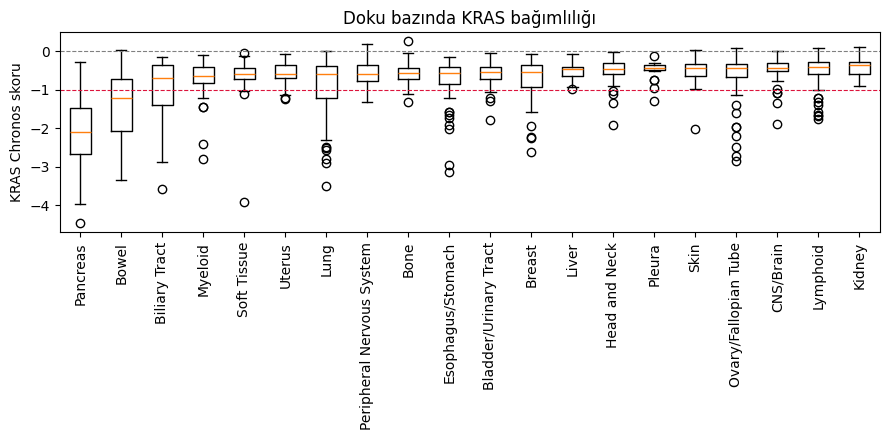

In [3]:
buyuk = doku.value_counts()
buyuk = buyuk[buyuk >= 20].index
veri = [kras[doku == d].values for d in buyuk]
sira = np.argsort([np.median(v) for v in veri])

plt.figure(figsize=(9, 4.5))
plt.boxplot([veri[i] for i in sira], labels=[buyuk[i] for i in sira], vert=True)
plt.axhline(-1, ls='--', lw=0.8, c='crimson')
plt.axhline(0, ls='--', lw=0.8, c='gray')
plt.xticks(rotation=90); plt.ylabel('KRAS Chronos skoru')
plt.title('Doku bazında KRAS bağımlılığı')
plt.tight_layout();

## 3. En bağımlı hatlar

Son olarak en uçtaki hatları adlarıyla görüyoruz. Bu isimler laboratuvar literatüründe tanıdık gelecek: KRAS mutasyonuyla bilinen pankreas ve akciğer hatları listenin başında olmalı.

Burada durup bir sınırı yazalım: elimizdeki veri yalnız bağımlılık skoru. Hangi hattın KRAS mutasyonu taşıdığını bu tablodan bilemeyiz — o bilgi başka bir DepMap dosyasında. Yani "bağımlı hatlar mutant mı" sorusunu bu defterde cevaplayamıyoruz; 4.5'in konusu bu.

In [4]:
en = kras.sort_values().head(15)
print(pd.DataFrame({
    'hat': kunye.loc[en.index, 'CellLineName'],
    'doku': kunye.loc[en.index, 'OncotreeLineage'],
    'skor': en.round(2)
}).to_string(index=False))

       hat              doku  skor
    AsPC-1          Pancreas -4.46
Panc 08.13          Pancreas -3.97
       RKN       Soft Tissue -3.92
Panc 04.03          Pancreas -3.66
     EGI-1     Biliary Tract -3.57
    Calu-6              Lung -3.50
   SNU-410          Pancreas -3.36
  SU.86.86          Pancreas -3.35
    SNU-61             Bowel -3.33
    PK-45H          Pancreas -3.31
MIA PaCa-2          Pancreas -3.27
Panc 02.03          Pancreas -3.27
    SW 626             Bowel -3.24
    SUIT-2          Pancreas -3.18
     SNU-1 Esophagus/Stomach -3.14


## Kendin dene

Üç görev. Birincisi: KRAS'ın medyan, çeyrek ve uç değerlerini, bağımlı hat sayısını ve oranını not edin. İkincisi: oran tablosundan en yüksek üç dokuyu yazın ve tek cümleyle açıklayın — ham sayı yerine oranla bakmak neden gerekliydi? Üçüncüsü: kendi seçtiğiniz bir geni aynı hattan geçirin (`sutun('GEN')` ile sütunu bulun, aynı adımları uygulayın); önerdiğim adaylar BRAF, EGFR, CTNNB1, SOX10 — hangi dokuda yoğunlaştığını ve bunun bilinen kanser biyolojisiyle uyuşup uyuşmadığını yazın.